<a href="https://colab.research.google.com/github/KelllyChen/2025-Fall-XAI-Explainable-Techniques-II/blob/notebook/Explainable_Techniques_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Techniques II
- Built a simple randomforest classifier based on the selected dataset and produced PDP, ICE, and ALE plots.
- Exploratory analysis is performed to determine the amount of correlation between features.  
- A comprehensive explanation of EDA and explainable plots are provided.
- Data can be found here: [Spotify Analysis Dataset 2025](https://www.kaggle.com/datasets/nabihazahid/spotify-dataset-for-churn-analysis)
- Did not use AI for codes and explaination generation in this notebook.


# Install and load packages

In [1]:
!pip install git+https://github.com/MaximeJumelle/ALEPython.git@dev#egg=alepython

  Cloning https://github.com/MaximeJumelle/ALEPython.git (to revision dev) to /tmp/pip-install-5oetw_nk/alepython_ea9406253d254e52a2204d827238420e
  Running command git clone --filter=blob:none --quiet https://github.com/MaximeJumelle/ALEPython.git /tmp/pip-install-5oetw_nk/alepython_ea9406253d254e52a2204d827238420e
  Resolved https://github.com/MaximeJumelle/ALEPython.git to commit 286350ab674980a32270db2a0b5ccca1380312a7
  Preparing metadata (setup.py) ... done


In [2]:
!pip install PyALE

In [3]:
!pip install "scipy<1.14"


In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# XAI
from alepython import ale_plot
from PyALE import ale
from sklearn.inspection import PartialDependenceDisplay

# Load Data

In [5]:
df = pd.read_csv('spotify_churn_dataset.csv')
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [6]:
df.isnull().any()

,0
user_id,False
gender,False
age,False
country,False
subscription_type,False
listening_time,False
songs_played_per_day,False
skip_rate,False
device_type,False
ads_listened_per_week,False


In [7]:
df.dtypes

,0
user_id,int64
gender,object
age,int64
country,object
subscription_type,object
listening_time,int64
songs_played_per_day,int64
skip_rate,float64
device_type,object
ads_listened_per_week,int64


In [8]:
df['is_churned'].value_counts()

,count
is_churned,
0,5929
1,2071


# Check correlation



In [9]:
co_features=['listening_time','songs_played_per_day','skip_rate','ads_listened_per_week']
for co_feature in co_features:
  group1 = df[df['subscription_type'] == "Family"][co_feature]
  group2 = df[df['subscription_type'] == "Free"][co_feature]
  group3 = df[df['subscription_type'] == "Premium"][co_feature]
  group4 = df[df['subscription_type'] == "Student"][co_feature]

  # applied ANOVA
  f_statistic, p_value = stats.f_oneway(group1, group2, group3, group4)
  print(f"P-value: {p_value}")

  # set the confidence level at 95%
  if p_value<0.05:
      print('subscription_type and '+ co_feature+ " have significant correlation\n")
  else:
      print('subscription_type and '+ co_feature+ " have no significant correlation\n")

P-value: 0.33316329512623327
subscription_type and listening_time have no significant correlation

P-value: 0.12887518950313928
subscription_type and songs_played_per_day have no significant correlation

P-value: 0.6954747267576555
subscription_type and skip_rate have no significant correlation

P-value: 0.0
subscription_type and ads_listened_per_week have significant correlation



In [10]:
co_features=['listening_time','songs_played_per_day','skip_rate','ads_listened_per_week']
for co_feature in co_features:
  group1 = df[df['country'] == "AU"][co_feature]
  group2 = df[df['country'] == "CA"][co_feature]
  group3 = df[df['country'] == "DE"][co_feature]
  group4 = df[df['country'] == "FR"][co_feature]
  group5 = df[df['country'] == "IN"][co_feature]
  group6 = df[df['country'] == "PK"][co_feature]
  group7 = df[df['country'] == "UK"][co_feature]

  # applied ANOVA
  f_statistic, p_value = stats.f_oneway(group1, group2, group3, group4)
  print(f"P-value: {p_value}")

  # set the confidence level at 95%
  if p_value<0.05:
      print('country and '+ co_feature+ " have significant correlation\n")
  else:
      print('country and '+ co_feature+ " have no significant correlation\n")

P-value: 0.45119046613546965
country and listening_time have no significant correlation

P-value: 0.08155710339867189
country and songs_played_per_day have no significant correlation

P-value: 0.6542143662106814
country and skip_rate have no significant correlation

P-value: 0.8016400472343073
country and ads_listened_per_week have no significant correlation



In [11]:
from scipy.stats import pearsonr

co_features=['listening_time','songs_played_per_day','skip_rate','ads_listened_per_week']

for f1, f2 in itertools.combinations(co_features, 2):

    # applied pearson
    r, p = pearsonr(df[f1], df[f2])
    print(f"P-value: {p}")

    # set the confidence level at 95%
    if p<0.05:
        print(f'{f1} and {f2} have significant correlation \n')
    else:
        print(f'{f1} and {f2} have no significant correlation \n')

P-value: 0.3254059343573887
listening_time and songs_played_per_day have no significant correlation 

P-value: 0.22378161261881
listening_time and skip_rate have no significant correlation 

P-value: 0.8385212200878711
listening_time and ads_listened_per_week have no significant correlation 

P-value: 0.957899149192258
songs_played_per_day and skip_rate have no significant correlation 

P-value: 0.11114096478089047
songs_played_per_day and ads_listened_per_week have no significant correlation 

P-value: 0.2567363977312722
skip_rate and ads_listened_per_week have no significant correlation 



### Correlation
- Categorical variable vs. numerical variable (ANOVA)
  - Considering the nature of the dataset itself, I only pick *country* and *subscription_type* to perform ANOVA with other numerical variables.
  - Based on the p-value, only *subscription_type* and *ads_listened_per_week* have significant correlation.
- Numerical variable vs. numerical variable (Pearson)
  - All numerical variables showed no significant correlations with one another.







# Model training

In [12]:
encoders = {}
label_cols = df.select_dtypes(include='object').columns.tolist()

for col in label_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df.drop(["user_id","is_churned"], axis=1)
y = df["is_churned"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train simple RF model
model = RandomForestClassifier(class_weight="balanced",random_state=42)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86      1200
           1       0.50      0.01      0.01       400

    accuracy                           0.75      1600
   macro avg       0.63      0.50      0.44      1600
weighted avg       0.69      0.75      0.65      1600



### Model Results
- RandonForest classfier shows high performance on class 0 (Active), but it performs really poor on class 1(churn) recall/ f1-score. This might be due to class imbalance, with class 0 having nearly three times as many instances as class 1.
- I tried using SMOTE before fitting the model because it could improve the performance by addressing class imbalance. But since the training set was resampled, the explanation plots could not show how the real data looked like, so I did not choose to do SMOTE at the end.

In [13]:
# Print out the label for future reference
for feature, le in encoders.items():
    print(f"\nMapping for {feature}:")
    for i, cls in enumerate(le.classes_):
        print(cls + ":", i)


Mapping for gender:
Female: 0
Male: 1
Other: 2

Mapping for country:
AU: 0
CA: 1
DE: 2
FR: 3
IN: 4
PK: 5
UK: 6
US: 7

Mapping for subscription_type:
Family: 0
Free: 1
Premium: 2
Student: 3

Mapping for device_type:
Desktop: 0
Mobile: 1
Web: 2


# PDP/ ALE

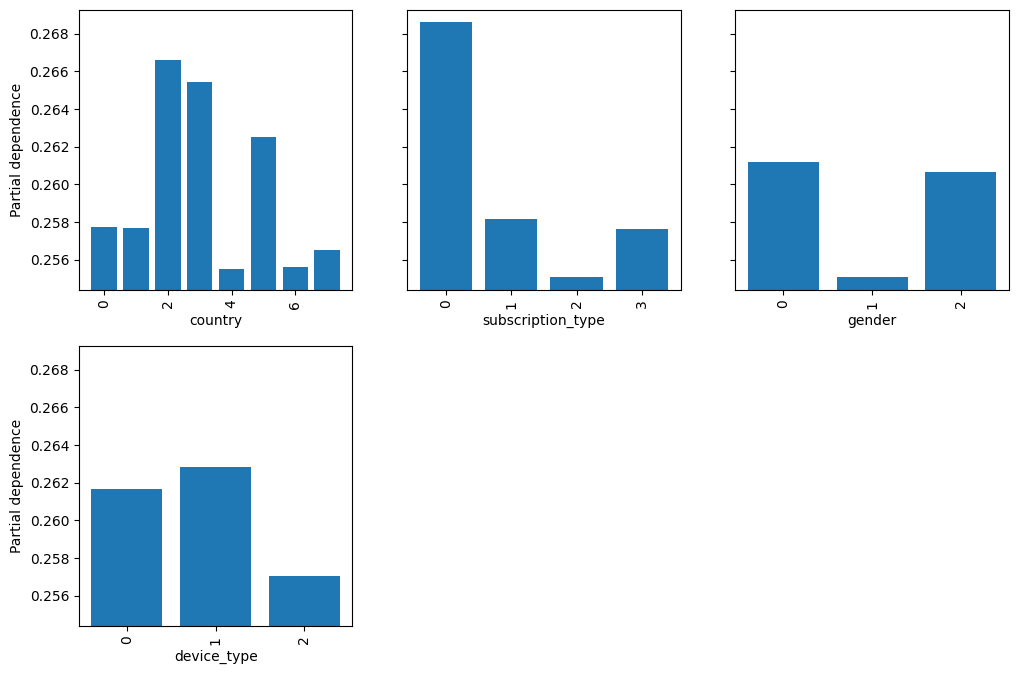

In [14]:
features = ["country","subscription_type","gender","device_type"]
fig, ax = plt.subplots(figsize=(12, 8))
# Use PartialDependenceDisplay to plot PDP
pdp = PartialDependenceDisplay.from_estimator(model, X_test, features, kind='average',categorical_features=features,ax=ax)



### PDP (Categorical features)
  - Country
    - Countries (DE, FR, PK) have a higher churn likelihood, while others are lower.
    - However, the variation between countries is relately small compared to subscription type.
  - Subscription type(0 = Family, 1 = Free, 2 = Premium, 3 = Student)
    - Family users have the highest predicted churn risk.
    - Premium users gave the lowest chrun probability
    - This aligns with domain intuition: Premium users are more committed.
    - Perhaps family plans have some flaws or inconveniences that lead to a high cancellation rate.
  - Gender(0 = Female, 1 = Male, 2 = Other)
    - Males have the lowest churn probability.
  - Device type(0 = Desktop, 1 = Mobile, 2 = Web)
    - Mobile users show slightly higher churn probability.
    - Web users have the lowest churn.
    - This is somewhat different from my intuition because I would expect people to use Spotify most frequently on their mobile phones and will keep the subscription because of its convience.


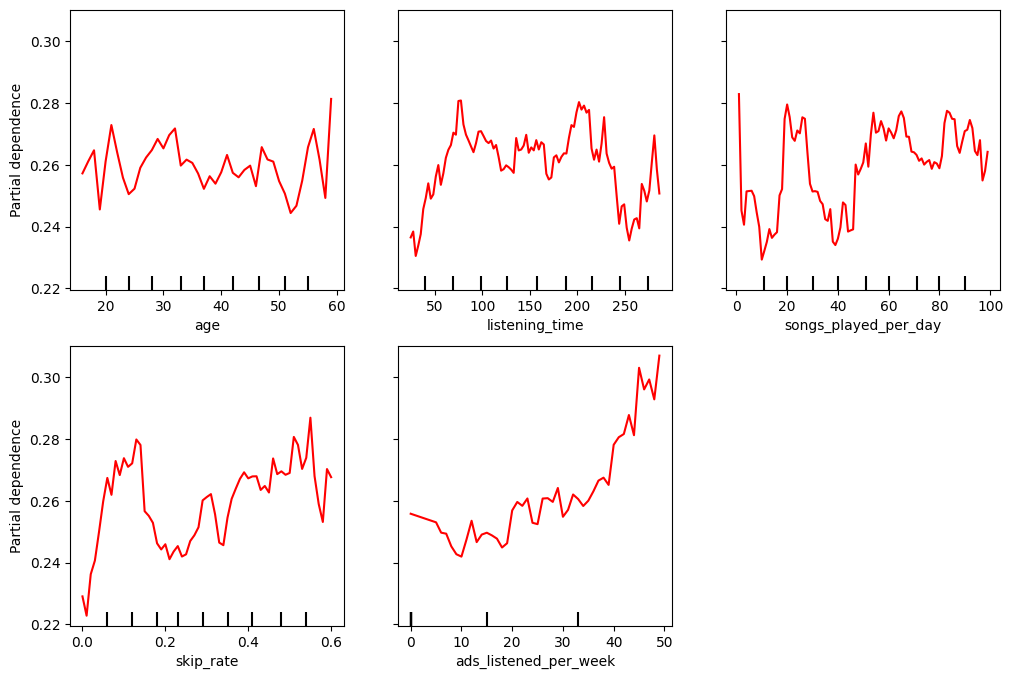

In [15]:
features = ['age','listening_time','songs_played_per_day','skip_rate','ads_listened_per_week']
fig, ax = plt.subplots(figsize=(12, 8))
# Use PartialDependenceDisplay to plot PDP
pdp = PartialDependenceDisplay.from_estimator(model, X_test, features, kind='average', ax=ax, line_kw={"color": "red"},ice_lines_kw={"color": "lightblue"})
plt.show()

### PDP (Continuous variables)
- Age
  - There is no clear trend in churn probability across different age groups.
- Listening time
  - Churn probability reaches its lowest point at around 50 and 250 minutes of listening time. This is an interesting finding, it’s understandable that users who listen more are more committed, but it’s also notable that those who listen less show lower churn probability as well.
- Ads listened per week
  - Among these five features, ads_listened_per_week has the strongest upward slope: the more ads listened to, the higher the churn probability. This aligns with the intuition assumption.
- For an overall interpretation, age is a relatively weak predictor, but engagement-related features like ads exposure, listening time, or skip rate have relatively clear affect on churn.


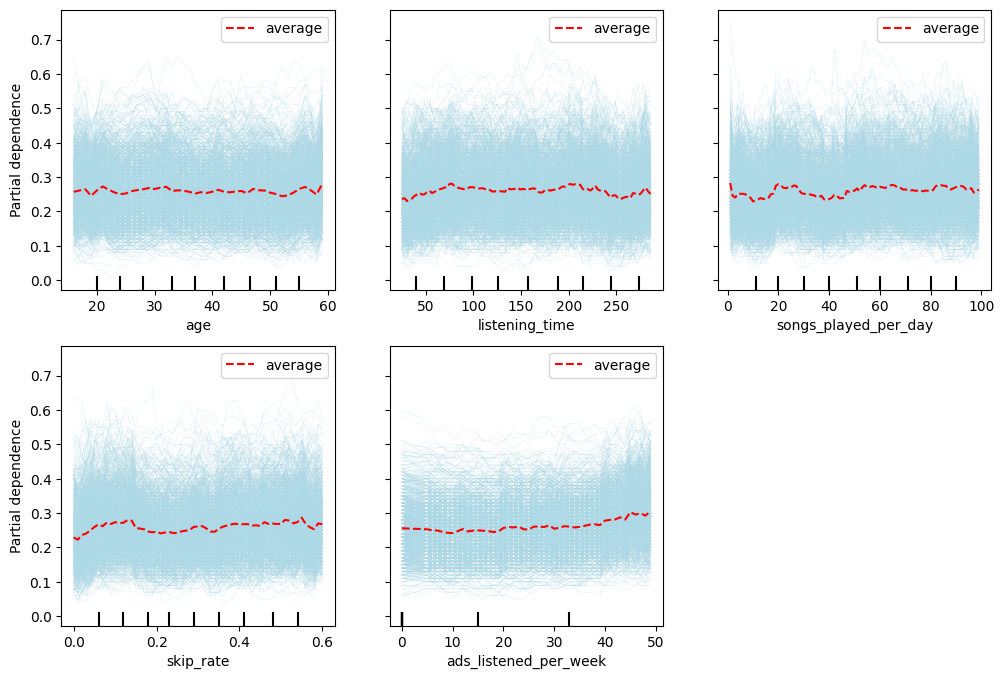

In [16]:
features = ['age','listening_time','songs_played_per_day','skip_rate','ads_listened_per_week']
fig, ax = plt.subplots(figsize=(12, 8))
# Use PartialDependenceDisplay to plot PDP
pdp = PartialDependenceDisplay.from_estimator(model, X_test, features, kind='both', ax=ax, line_kw={"color": "red"},ice_lines_kw={"color": "lightblue"})
plt.show()

/tmp/ipython-input-2845990427.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '16.877551020408163' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  instance_modified.iloc[:, feature_index] = value


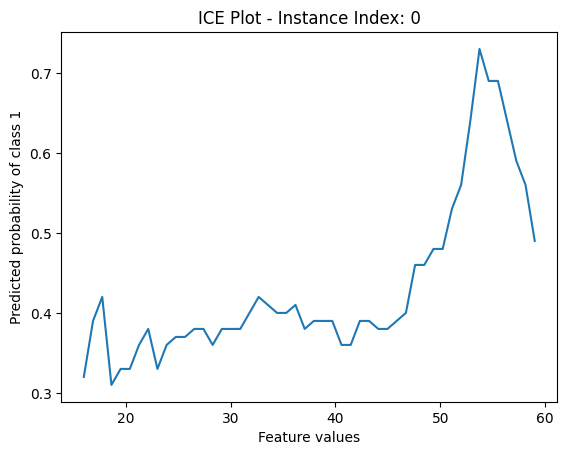

/tmp/ipython-input-2845990427.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '15.89795918367347' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  instance_modified.iloc[:, feature_index] = value


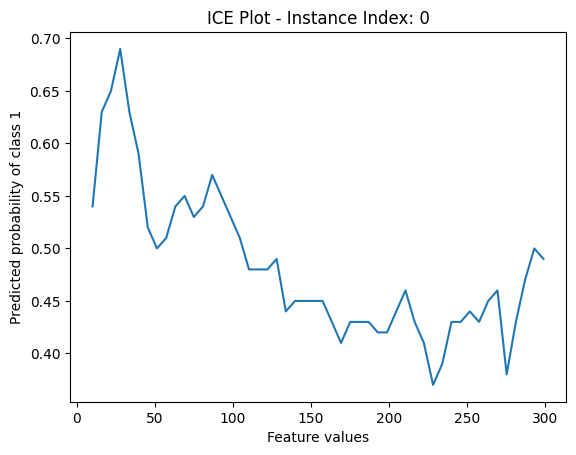

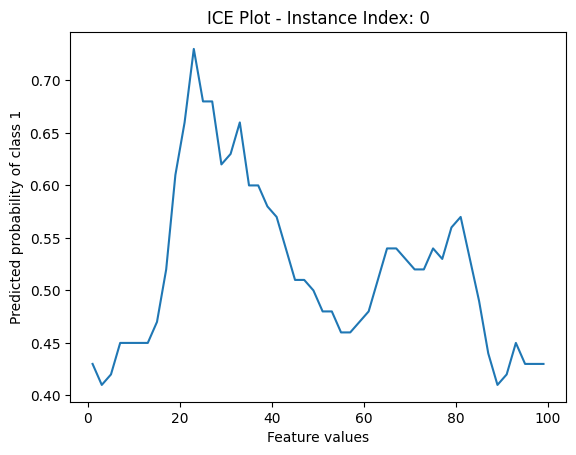

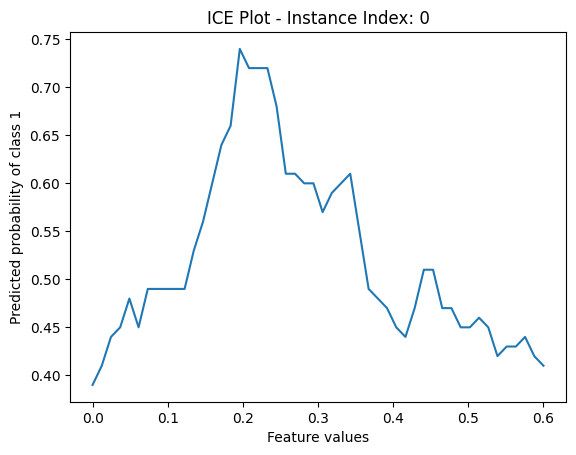

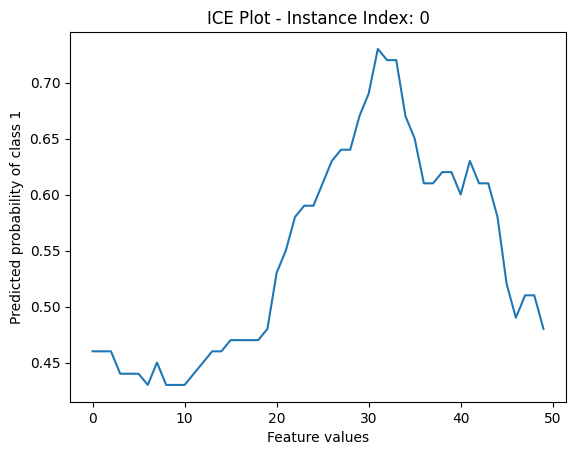

In [17]:
# This cell was copied and slightly modified from class github
feature_indices = [1,4, 5, 6,8]
for feature_index in feature_indices:
  # Choose the instance and feature for which you want to plot the ICE plot
  instance_index = 0  # Choose the index of the instance you want to visualize
  feature_index = feature_index

  # Create feature grid
  feature_values = np.linspace(np.min(X.iloc[:, feature_index]), np.max(X.iloc[:, feature_index]), num=50)

  # Initialize array to store average predictions
  average_predictions = np.zeros_like(feature_values)

  # Extract the instance of interest
  instance = X.iloc[[instance_index]]

  # Duplicate the instance to modify feature values
  instance_modified = instance.copy()

  # Loop over feature values
  for i, value in enumerate(feature_values):
      # Set the chosen feature to the current value for the instance:
      instance_modified.iloc[:, feature_index] = value

      # Predict using the modified instance:
      prediction = model.predict_proba(instance_modified)[:, 1]

      # Store the prediction for the current feature value:
      average_predictions[i] = prediction.item()

  # Plot the ICE plot
  plt.plot(feature_values, average_predictions)
  plt.xlabel(f'Feature values')
  plt.ylabel('Predicted probability of class 1')
  plt.title(f'ICE Plot - Instance Index: {instance_index}')
  plt.show()



/tmp/ipython-input-319515056.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '16.877551020408163' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  instance_modified.iloc[:, feature_index] = value


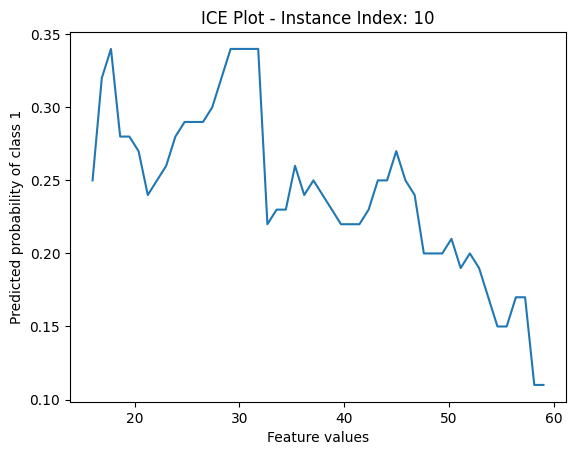

/tmp/ipython-input-319515056.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '15.89795918367347' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  instance_modified.iloc[:, feature_index] = value


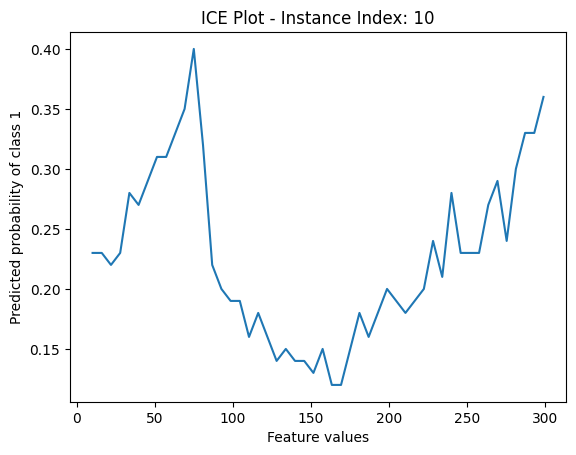

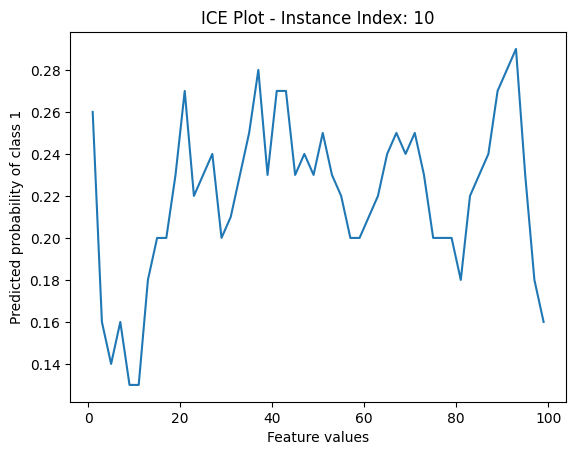

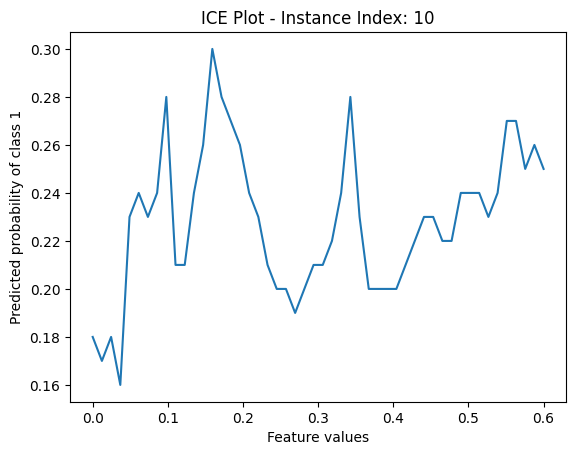

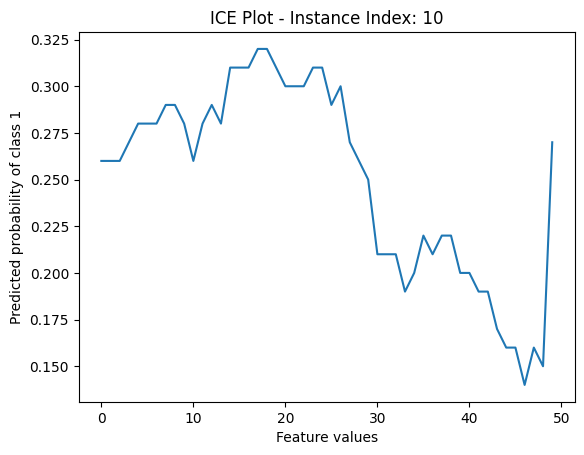

In [18]:
# This cell was copied and slightly modified from class github
feature_indices = [1,4, 5, 6,8]
for feature_index in feature_indices:
  # Choose the instance and feature for which you want to plot the ICE plot
  instance_index = 10  # Choose the index of the instance you want to visualize
  feature_index = feature_index

  # Create feature grid
  feature_values = np.linspace(np.min(X.iloc[:, feature_index]), np.max(X.iloc[:, feature_index]), num=50)

  # Initialize array to store average predictions
  average_predictions = np.zeros_like(feature_values)

  # Extract the instance of interest
  instance = X.iloc[[instance_index]]

  # Duplicate the instance to modify feature values
  instance_modified = instance.copy()

  # Loop over feature values
  for i, value in enumerate(feature_values):
      # Set the chosen feature to the current value for the instance:
      instance_modified.iloc[:, feature_index] = value

      # Predict using the modified instance:
      prediction = model.predict_proba(instance_modified)[:, 1]

      # Store the prediction for the current feature value:
      average_predictions[i] = prediction.item()

  # Plot the ICE plot
  plt.plot(feature_values, average_predictions)
  plt.xlabel(f'Feature values')
  plt.ylabel('Predicted probability of class 1')
  plt.title(f'ICE Plot - Instance Index: {instance_index}')
  plt.show()



### ICE (Continuous Variables)
- Notice that in the PDP plots for both categorical and numerical features, the y-axis range is very narrow. This indicates that the average marginal effect of each feature on churn prediction is small. However, when looking at single-user ICE plots (here I took the first and the 11th user), clear trends with larger changes in churn probability emerge for some features on certain users. This means that while features may have little impact on average, they can have strong effects for specific individuals, which are masked in the PDP averages.

### How this connects to the model result
- **PDP:** Shows features gave small average effects, which means the model does not push predictions strongly toward churn
- **ICE:** Taking the first user as an example, we can see a larger swing on prediction, listening time shifts churn probability from 0.4 to above 0.7. However, such cases may be rare. For example, the listening time effect for the 11th user is much smaller (0.14–0.28). Since users like the first one may be uncommon, the overall average effect remains weak, and globally the model still underpredicts churn.

# ALE

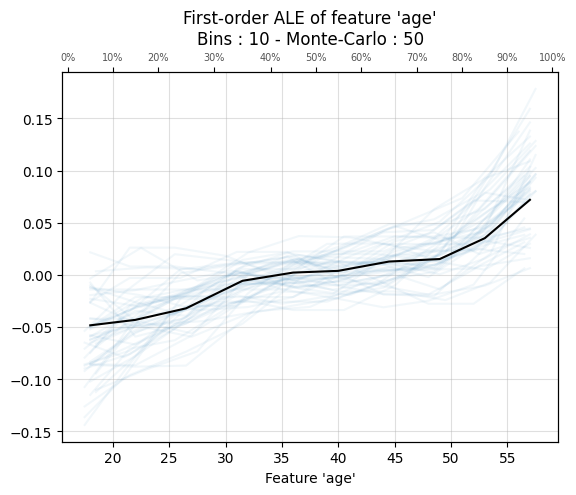

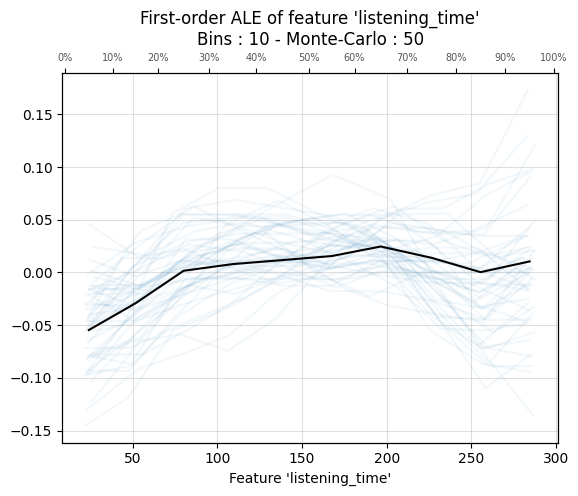

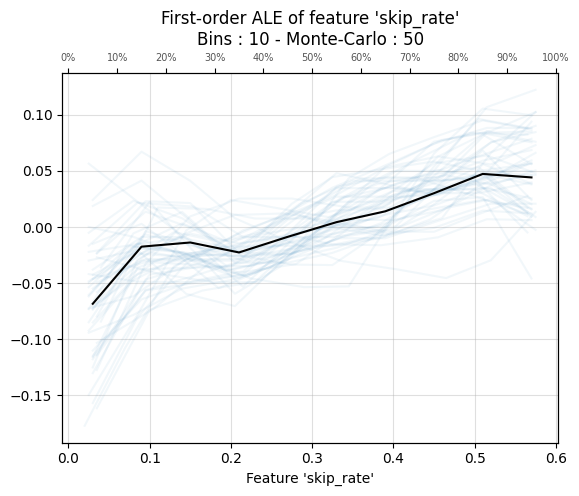

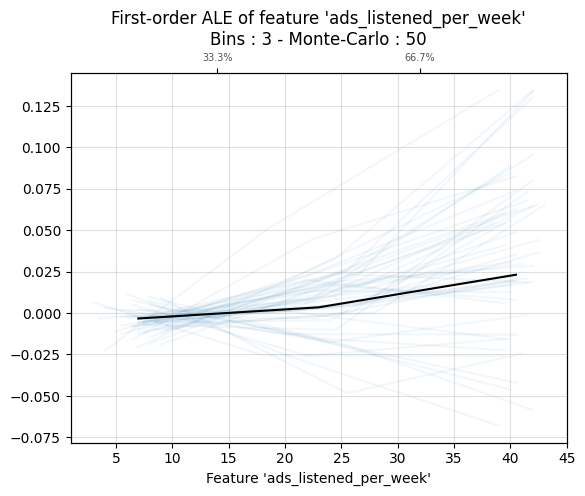

In [19]:
features=['age','listening_time','skip_rate','ads_listened_per_week']

for feature in features:
  ale_plot(model, X_train, feature, monte_carlo=True)

### ID ALE (Continuous Variables)
- Age
  - The line slopes upward means that older users have a higher predicted churn risk on average.
  - However, the effect is modest, range from -0.05 to around 0.1, so age is not a dominant factor.
- Listening Time
  - The trend looks similar to PDP, churn probability reaches its lowest point at around 50 and 250 minutes
- Skip Rate
  - Clear upward slope: higher skip rate leads to higher churn probability
  - Very consistent across samples, so we can tell that skip rate is a reliable churn signal.
- Ads Listened per Week
  - Small upward trend: more adds listened leads to higher churn probability.
  - The trend aligns with the above PDP plot, but the effect is smaller and smoother on ALE. This is because ALE accounts for correlations, we know that ads_listened_per_week and subscription_type are highly correlated from the ANOVA. Premium users should't have ads, so ALE avoids misleading impossible combinations that PDP averages might include.


INFO:PyALE._ALE_generic:Discrete feature detected.
INFO:PyALE._ALE_generic:Discrete feature detected.
INFO:PyALE._ALE_generic:Discrete feature detected.
INFO:PyALE._ALE_generic:Discrete feature detected.


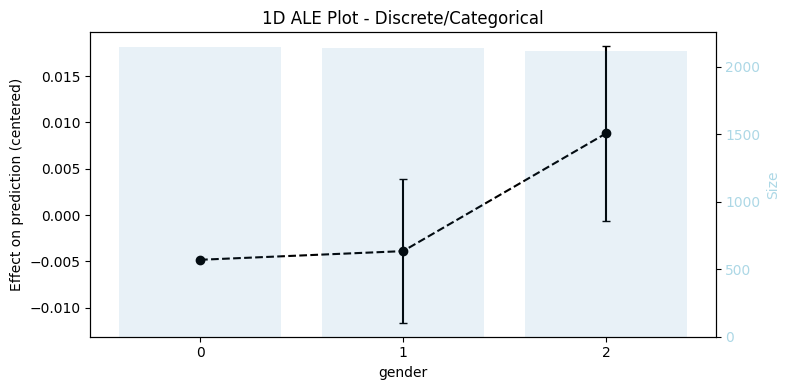

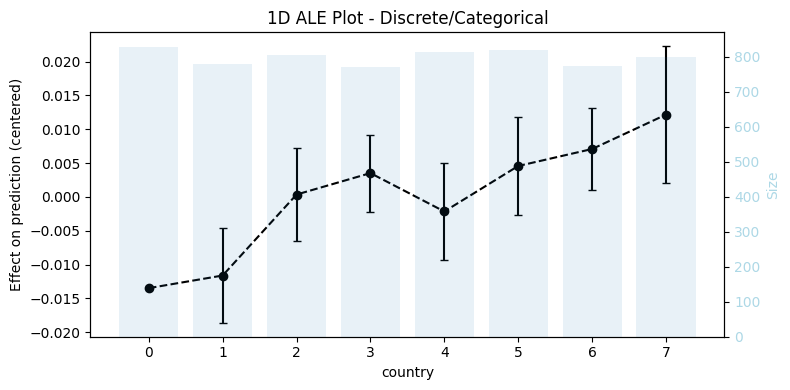

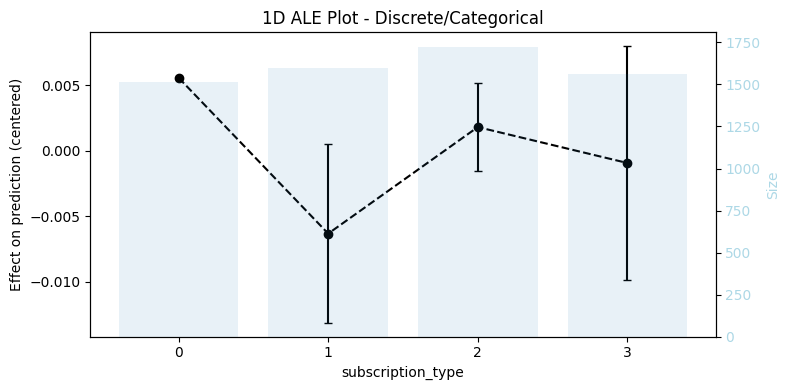

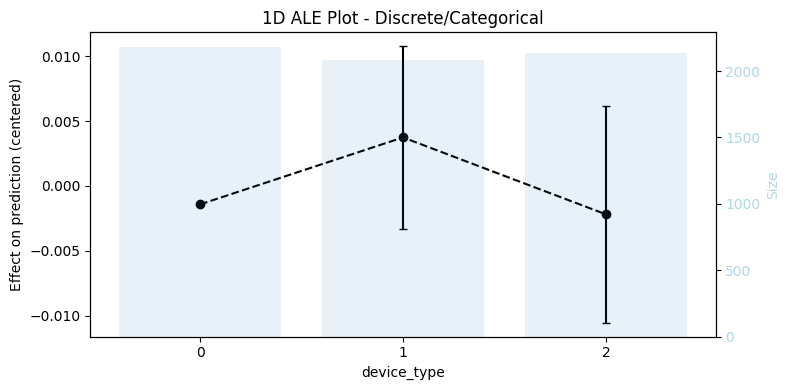

In [20]:
features=['gender','country','subscription_type','device_type']
for feature in features:
  ale_eff = ale(X=X_train, model=model, feature=[feature])


### ICE (Categorical Variables)
- From PDP, we know that subscription type and device type have relatively strong effect to the predicted values compared to two other categorical features.
- Same as what PDP shows, users with family plans and mobile phone users are more likely to cancel subscriptions.

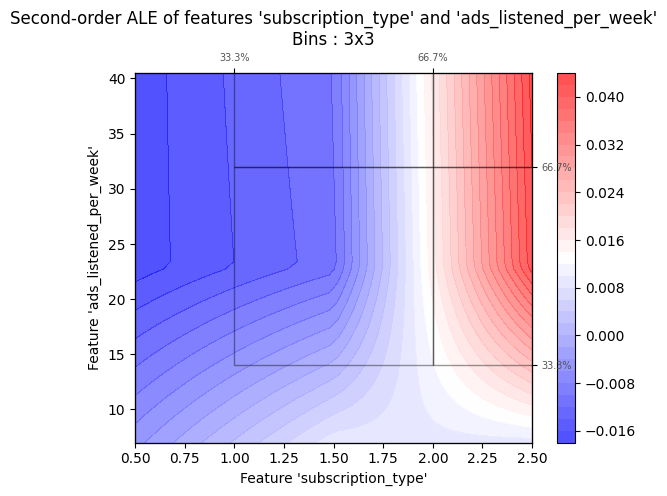

<Axes: title={'center': "Second-order ALE of features 'subscription_type' and 'ads_listened_per_week'\nBins : 3x3"}, xlabel="Feature 'subscription_type'", ylabel="Feature 'ads_listened_per_week'">

In [21]:
ale_plot(model, X_train, [ "subscription_type", "ads_listened_per_week",], bins=10)

### 2D ALE (Ads × Subscription Type)
- For Premium users, subscription_type=2 (who don’t see ads), churn stays low. This means that ALE captures the realistic constraint.
- However, need to be cautious that the interpretation of this plot, since sunscription type is categorical data, ALE will interpolate between categories (like 1.5 between Free (1) and Premium (2)), which is not meaningful.

### PDP vs ALE
- **PDP**
  - PDP averages effects across all users.
  - It can be misleading if features are correlated, for example, premium users do not have adds, but PDP still consider it.
  - This is why ads looks like a stronger effect on PDP
- **ALE**
  - ALE focuses only on realistic ranges of features.
  - For ads × subscription type, ALE correctly shows that ads does not matter for premium user.
